<a href="https://colab.research.google.com/github/FurkanOznamli/Machine_Learning/blob/CNN/CNN_Uygulama1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, random, numpy as np, tensorflow as tf
tf.__version__

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU var mı kontrol
gpus = tf.config.list_physical_devices('GPU')
print("GPU:", gpus)


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.datasets import cifar10

# Eğitim: 50k, Test: 10k
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

class_names = ["uçak","araba","kuş","kedi","geyik","köpek","kurbağa","at","gemi","kamyon"]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
x_train: (50000, 32, 32, 3) y_train: (50000, 1)
x_test: (10000, 32, 32, 3) y_test: (10000, 1)


In [ ]:
from tensorflow.keras.utils import to_categorical

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test,  num_classes=10)

print("Örnek piksel min/max:", x_train.min(), x_train.max())
print("Örnek etiket:", y_train[0], "->", y_train_oh[0])


Örnek piksel min/max: 0.0 1.0
Örnek etiket: [6] -> [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [ ]:
from tensorflow.keras import layers, models

def build_cnn():
    inputs = layers.Input(shape=(32,32,3))

    # 1. blok
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # 2. blok
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # 3. blok
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.35)(x)

    # Tam bağlantılı katmanlar
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="cnn_cifar10")
    return model

model = build_cnn()
model.summary()


Model: "cnn_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    x_train, y_train_oh,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.2822 - loss: 1.9114 - val_accuracy: 0.5038 - val_loss: 1.3499 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4880 - loss: 1.4081 - val_accuracy: 0.6088 - val_loss: 1.1097 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5537 - loss: 1.2402 - val_accuracy: 0.6446 - val_loss: 1.0080 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5913 - loss: 1.1484 - val_accuracy: 0.6794 - val_loss: 0.9180 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6196 - loss: 1.0721 - val_accuracy: 0.6992 - val_loss: 0.8711 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6392 - loss: 1.0245 - val_accuracy: 0.6980 - val_loss: 0.8613 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6499 - loss: 0.9957 

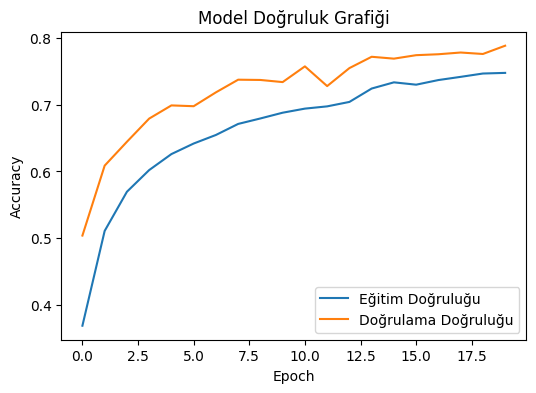

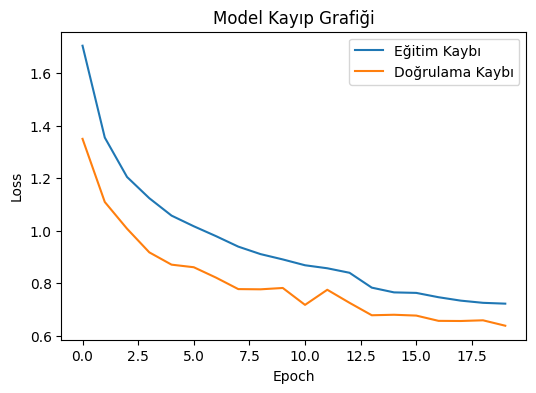

In [ ]:
import matplotlib.pyplot as plt

def plot_training(h):
    plt.figure(figsize=(6,4))
    plt.plot(h.history["accuracy"], label="Eğitim Doğruluğu")
    plt.plot(h.history["val_accuracy"], label="Doğrulama Doğruluğu")
    plt.title("Model Doğruluk Grafiği")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(h.history["loss"], label="Eğitim Kaybı")
    plt.plot(h.history["val_loss"], label="Doğrulama Kaybı")
    plt.title("Model Kayıp Grafiği")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_training(history)


In [ ]:
# Test verisi üzerinde performans ölçümü
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 0.6726
Test Accuracy: 0.7698


              precision    recall  f1-score   support

        uçak       0.82      0.77      0.79      1000
       araba       0.89      0.88      0.89      1000
         kuş       0.72      0.61      0.66      1000
        kedi       0.69      0.51      0.59      1000
       geyik       0.66      0.80      0.72      1000
       köpek       0.69      0.68      0.69      1000
     kurbağa       0.80      0.85      0.83      1000
          at       0.79      0.82      0.80      1000
        gemi       0.80      0.93      0.86      1000
      kamyon       0.84      0.85      0.84      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



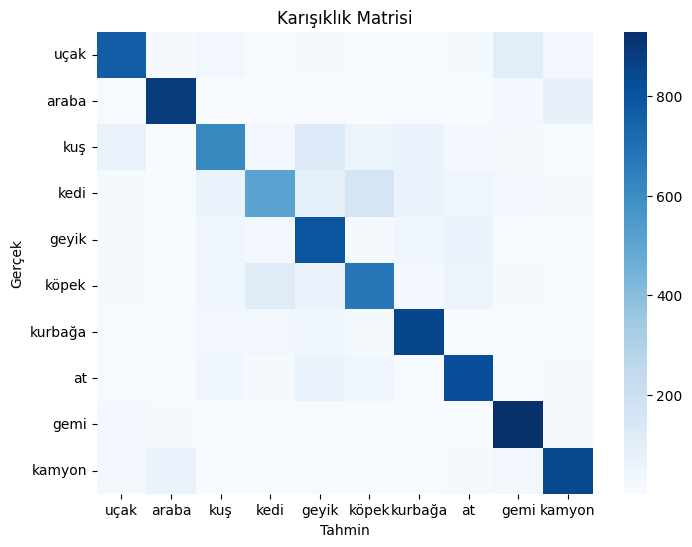

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Tahminleri al
y_pred_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

# Sınıflandırma raporu
print(classification_report(y_true, y_pred, target_names=class_names))

# Karışıklık matrisi
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Karışıklık Matrisi")
plt.show()


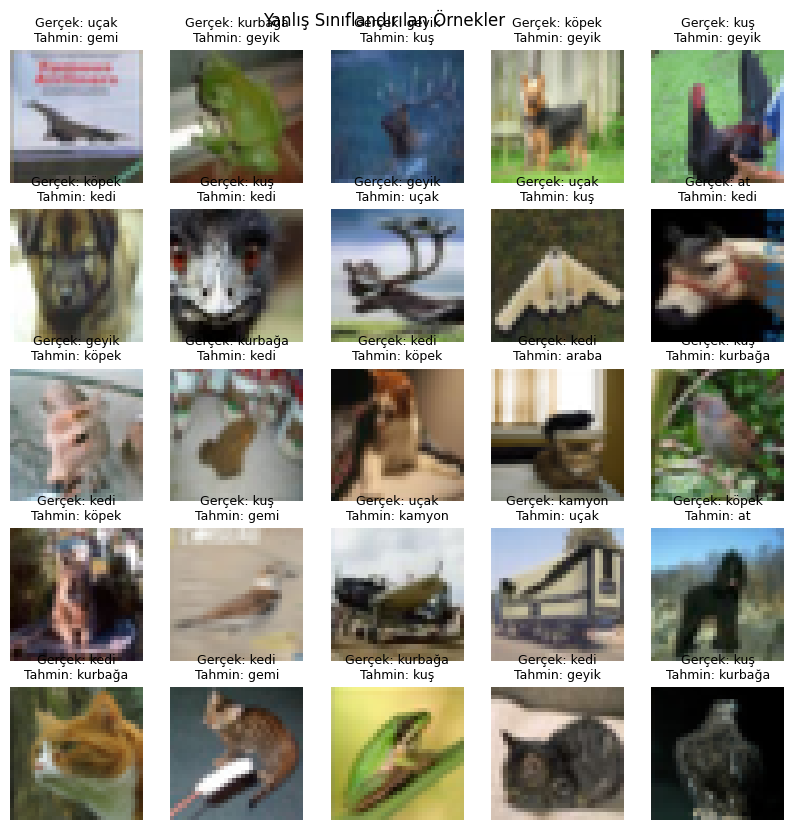

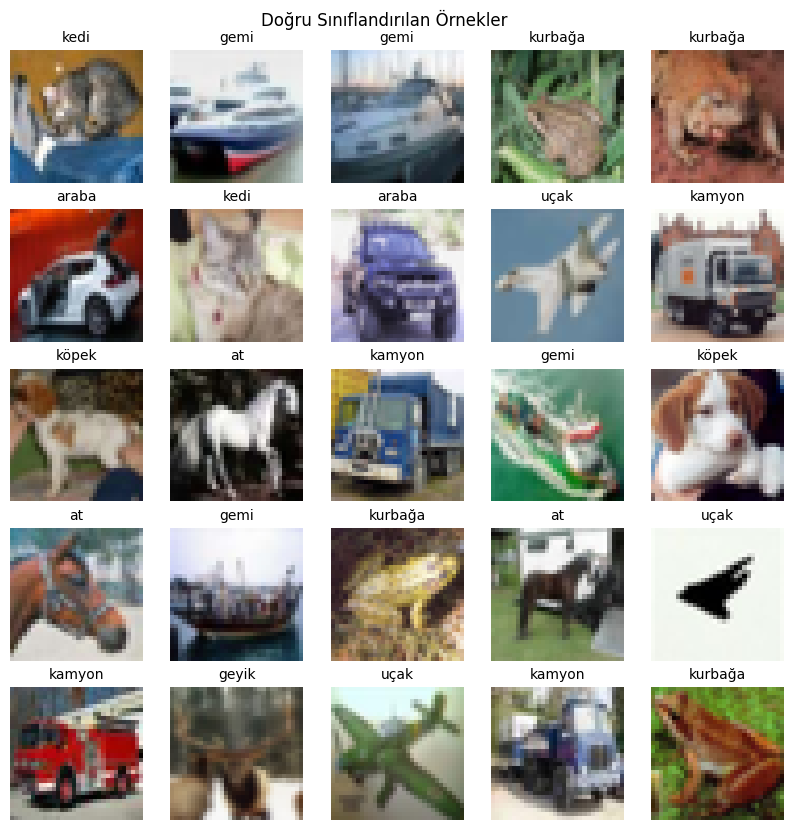

In [ ]:
# Yanlış sınıflandırılmış örneklerden 25 tanesini göster
idx_wrong = np.where(y_pred != y_true)[0][:25]

plt.figure(figsize=(10,10))
for i, idx in enumerate(idx_wrong):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    plt.title(f"Gerçek: {class_names[y_true[idx]]}\nTahmin: {class_names[y_pred[idx]]}", fontsize=9)
plt.suptitle("Yanlış Sınıflandırılan Örnekler", y=0.92)
plt.show()

# Doğru sınıflandırılmış örneklerden 25 tanesini göster
idx_right = np.where(y_pred == y_true)[0][:25]

plt.figure(figsize=(10,10))
for i, idx in enumerate(idx_right):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    plt.title(f"{class_names[y_true[idx]]}", fontsize=10)
plt.suptitle("Doğru Sınıflandırılan Örnekler", y=0.92)
plt.show()


In [ ]:
# Modeli kaydet
model.save("cnn_uygulama1.h5")
print("✅ Model başarıyla kaydedildi: cnn_uygulama1.h5")


✅ Model başarıyla kaydedildi: cnn_uygulama1.h5
